# Emotion Classification with RNNs, LSTMs & GRUs

Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU**.

## 1. Import Libraries
Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#dataset load krwane mai help karegi
from datasets import load_dataset

## 2. Load Dataset
Load the `dair-ai/emotion` dataset from Hugging Face.
https://huggingface.co/datasets/dair-ai/emotion

In [ ]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [ ]:
label_names = emotion_dataset['train'].features['label'].names

In [ ]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [ ]:
df_train.isnull().sum()

,0
text,0
label,0


## 3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

In [ ]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

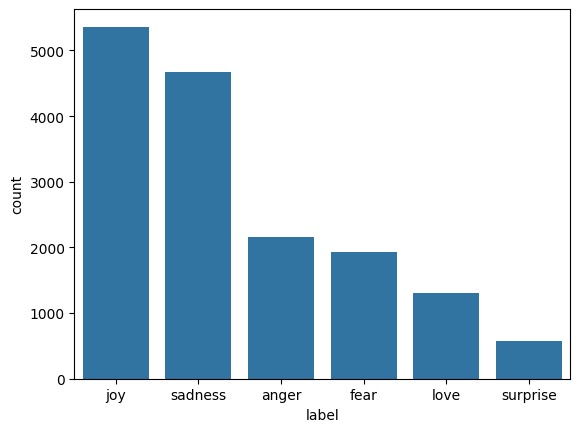

In [ ]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [ ]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


## 4. Data Preprocessing - Using NLP
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
print(num_classes)


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

6
Vocabulary Size: 15213
Max Sentence Length: 50


## 5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.

In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 6. Phase 1 — Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

### 6.1 Model 1 — Simple RNN
Plain unrolled Recurrent Neural Network.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.1614 - loss: 1.9067 - val_accuracy: 0.0615 - val_loss: 1.8171
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1607 - loss: 1.8002 - val_accuracy: 0.0960 - val_loss: 1.8155
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.1691 - loss: 1.7731 - val_accuracy: 0.1390 - val_loss: 1.7933
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.1689 - loss: 1.7583 - val_accuracy: 0.1155 - val_loss: 1.8360
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - accuracy: 0.1621 - loss: 1.7471 - val_accuracy: 0.1355 - val_loss: 1.7824
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.1768 - loss: 1.7218 - val_accuracy: 0.1290 - val_loss: 1.7990
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.1672 - loss: 1.7275 - val_accuracy: 0.1780 - val_loss: 1.7869
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.1834 - loss: 1.7006 - 

KeyboardInterrupt: 

### 6.2 Model 2 — Standard LSTM
Plain stacked Long Short-Term Memory network.

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

### 6.3 Model 3 — Standard GRU
Plain stacked Gated Recurrent Unit network.

In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

### 6.4 Phase 1 Ranking & Selection
Rank foundational models to pick the best base cell for Phase 2.

In [ ]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

## 7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

### 7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [ ]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

#### Train & Evaluate Advanced Bidirectional GRU

In [ ]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

In [ ]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

## 8. Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

### 8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

In [ ]:
# sadness=5%,joy=14%,anger=67%,love=9%,suprise=50%,fear=2%

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

## 9. Final Predictions
Test the winning model on unseen sample sentences.

In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

## 10. Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [ ]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)

In [ ]:
label_names

Saved artifact at '/tmp/tmpcrl_zoyq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(32, 50), dtype=tf.float32, name='input_layer_11')
Output Type:
  TensorSpec(shape=(32, 6), dtype=tf.float32, name=None)
Captures:
  134863733043664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134861358293712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134861358291024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134861358292752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134861358290832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134861358291984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134861358293328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134861283217040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134861283222416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134861283213392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134861283223376: TensorSp